In [1]:
import scanpy as sc
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import decoupler

import os
import sys
import logging
import warnings

/ocean/projects/cis240075p/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load file path from ocean
adata_infile = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/All_Cell_Types.h5ad'
adata_infile_fiber = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/Myofiber_scsn_RNA.h5ad'
adata_male_file = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp/myofibers_male.h5ad'
adata_female_file = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp/myofibers_female.h5ad'
out_tmp = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp'

In [3]:
adata_male = sc.read_h5ad(adata_male_file)
adata_female = sc.read_h5ad(adata_female_file)

# Myofiber analysis

In [4]:
adata_male

AnnData object with n_obs × n_vars = 74348 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'GOBP_DNA_DAMAGE_RESPONSE', 'REACTOME_DNA_REPAIR', 'DNA_DAMAGE_CHECKPOINT', 'REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'GOBP_FATTY_ACID_BETA_OXIDATION', 'KEGG_CITRATE_CYCLE_TCA_CYCLE', 'KEGG_GLYCOLYSIS_GLUCONEOGENESIS', 'KEGG_OXIDATIVE_PHOSPHORYLATION', 'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM', 'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM', 'Atrophy Pathway'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'Sex_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors

In [ ]:
#subset by type
adata_male_type_II = adata_male[adata_male.obs['Annotation'] == 'Type II'].copy()
adata_male_type_I = adata_male[adata_male.obs['Annotation'] == 'Type I'].copy()
# gene expression dot plots of atrophy pathway
sc.pl.dotplot(adata_male_type_II, title='Type II', var_names=['UBB','UBC','FBXO32','TRIM63','MDM2','FBXO30','CAMK2B','TIE1','PSMA1','PSMA2','PSMA3','PSMA4','PSMA5','PSMA6','PSMA7','PSMB1','PSMB2','PSMB3','PSMB4','FBXO21','FBXO31','NEDD4','UBE2B','UBE2G1','UBE2J1','CTSL','CTSV','BNIP3','DEPP1','GABARAPL1','RETREG1','SQSTM1','CAPN1','CAPN2','ATF4','FOXO1','HDAC9','RUNX1','AMPD3','CHRNA1','CDKN1A'], groupby='sample', dendrogram=False)


In [ ]:
# count the number of cells in each age
display(adata_male.obs['sample'].value_counts())

sample
OM5    11986
P5      8992
OM7     5693
P13     2949
Name: count, dtype: int64

## Molecular age (pseudotime based) of each sample

/tmp/ipykernel_98260/197111160.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_summary_df = obs_df_valid_pt.groupby('sample').agg(


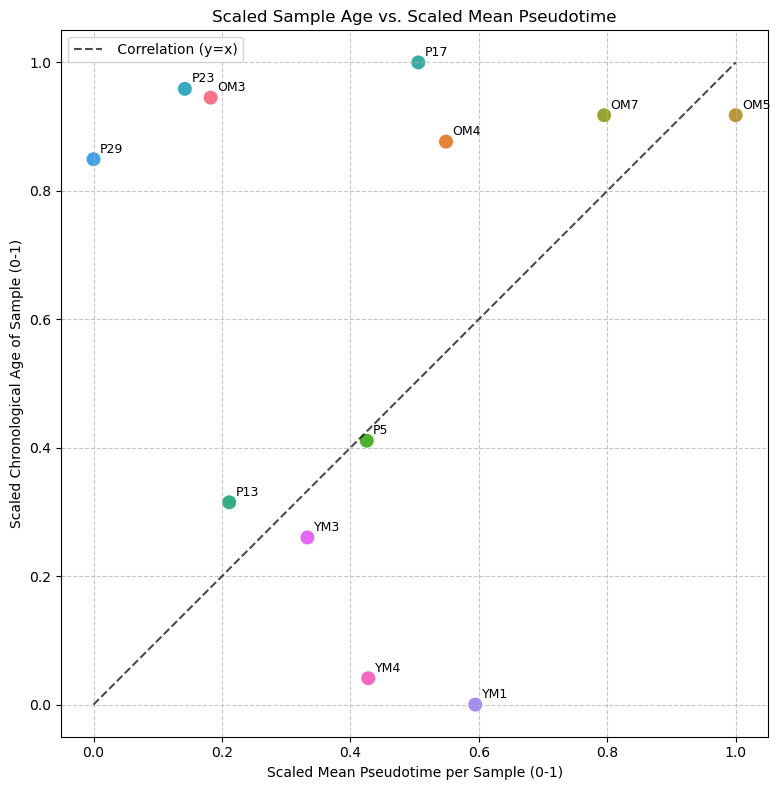

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

def plot_age_vs_pseudotime(adata, figsize=(10, 8), point_size=120, show_plot=True):
    """
    Plot scaled sample age vs scaled mean pseudotime.
    
    Parameters:
    -----------
    adata : AnnData object
        Annotated data object containing obs with 'sample', 'age', 'Pseudotime' columns
    figsize : tuple, default (10, 8)
        Figure size for the plot
    point_size : int, default 120
        Size of scatter plot points
    show_plot : bool, default True
        Whether to display the plot
    
    Returns:
    --------
    matplotlib.figure.Figure
        The generated figure object
    pandas.DataFrame
        Summary dataframe with scaled values
    """
    
    # 1. Select relevant columns and create a working copy
    obs_df = adata.obs[['sample', 'age', 'Pseudotime']].copy()
    
    # 2. Filter out cells where Pseudotime is NaN
    obs_df_valid_pt = obs_df.dropna(subset=['Pseudotime'])
    
    if obs_df_valid_pt.empty:
        print("No cells with valid pseudotime values found. Cannot proceed.")
        return None, None
    
    # 3. Group by 'sample' and aggregate
    sample_summary_df = obs_df_valid_pt.groupby('sample').agg(
        mean_pseudotime=('Pseudotime', 'mean'),
        age=('age', 'first')
    ).reset_index()
    
    # 4. Scale 'mean_pseudotime' and 'age' to 0-1 range
    if sample_summary_df.empty:
        print("Summary DataFrame is empty after grouping. Cannot plot.")
        return None, None
    
    scaler = MinMaxScaler()
    # Scale 'mean_pseudotime'
    sample_summary_df['scaled_mean_pseudotime'] = scaler.fit_transform(
        sample_summary_df[['mean_pseudotime']]
    )
    # Scale 'age'
    sample_summary_df['scaled_age'] = scaler.fit_transform(
        sample_summary_df[['age']]
    )
    
    # 5. Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    scatter_plot = sns.scatterplot(
        data=sample_summary_df,
        x='scaled_mean_pseudotime',
        y='scaled_age',
        hue='sample',
        s=point_size,
        legend=False,
        ax=ax
    )
    
    # Add labels for each point (sample ID)
    for i, row in sample_summary_df.iterrows():
        ax.text(
            row['scaled_mean_pseudotime'] + 0.01,
            row['scaled_age'] + 0.01,
            row['sample'],
            fontsize=9
        )
    
    # Add a y=x line for reference (perfect correlation)
    min_val = 0  # Since data is scaled 0-1
    max_val = 1
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label=" Correlation (y=x)")
    
    # Formatting
    ax.set_xlabel("Scaled Mean Pseudotime per Sample (0-1)")
    ax.set_ylabel("Scaled Chronological Age of Sample (0-1)")
    ax.set_title("Scaled Sample Age vs. Scaled Mean Pseudotime")
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc="upper left")
    ax.set_aspect('equal')  # Make the plot square for easier y=x interpretation
    ax.set_xlim(-0.05, 1.05)  # Give a little padding
    ax.set_ylim(-0.05, 1.05)  # Give a little padding
    
    plt.tight_layout()
    
    if show_plot:
        plt.show()
    return fig, sample_summary_df


fig, summary_df = plot_age_vs_pseudotime(adata_male)

# AUCell activity scoring of specific pathways

In [28]:
from pathlib import Path
from itertools import chain, repeat

def gmt_to_decoupler(pth: Path) -> pd.DataFrame:
    """Parse a gmt file to a decoupler pathway dataframe."""
    from itertools import chain, repeat

    pathways = {}

    with Path(pth).open("r") as f:
        for line in f:
            name, _, *genes = line.strip().split("\t")
            pathways[name] = genes

    return pd.DataFrame.from_records(
        chain.from_iterable(zip(repeat(k), v) for k, v in pathways.items()),
        columns=["geneset", "genesymbol"],
    )

def gmt_to_decoupler_multiple_pathways(gmt_paths):
    """Parse multiple gmt files and return a combined decoupler pathway dataframe."""
    all_records = []
    for pth in gmt_paths:
        with Path(pth).open("r") as f:
            for line in f:
                name, _, *genes = line.strip().split("\t")
                all_records.extend(zip(repeat(name), genes))
    return pd.DataFrame.from_records(all_records, columns=["geneset", "genesymbol"])

In [29]:
# load geneset of interest
# geneset_gmt = ["/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/GOBP_FATTY_ACID_BETA_OXIDATION.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_CITRATE_CYCLE_TCA_CYCLE.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_GLYCOLYSIS_GLUCONEOGENESIS.v2024.1.Hs.gmt",
#                "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_OXIDATIVE_PHOSPHORYLATION.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM.v2024.1.Hs.gmt"]
# geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt)
geneset_gmt = ["/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/DNA_DAMAGE_CHECKPOINT.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/GOBP_DNA_DAMAGE_RESPONSE.v2024.1.Hs.gmt", 
               "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/GOBP_DNA_REPAIR.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/HALLMARK_DNA_REPAIR.v2024.1.Hs.gmt",
               "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/REACTOME_DNA_REPAIR.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS.v2024.1.Hs.gmt"]
geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt)
# get the number of rows in each unique geneset
geneset_size = geneset_df['geneset'].value_counts()
display(geneset_size)

# custom_atrophy_pathway = ["UBB","UBC","FBXO32","TRIM63","MDM2","FBXO30","CAMK2B","TIE1","PSMA1","PSMA2","PSMA3","PSMA4","PSMA5","PSMA6","PSMA7","PSMB1","PSMB2","PSMB3","PSMB4","FBXO21","FBXO31","NEDD4","UBE2B","UBE2G1","UBE2J1","CTSL","CTSV","BNIP3","DEPP1","GABARAPL1","MAP1LC3","RETREG1","SQSTM1","CAPN1","CAPN2","ATF4","FOXO1","FOXO3A","HDAC9","RUNX1","AMPD3","CHRNA1","CDKN1A"]
# geneset_df = pd.DataFrame({'geneset': "Atrophy Pathway (PMID: 31325479)", 'genesymbol': custom_atrophy_pathway})
# geneset_df


geneset
GOBP_DNA_DAMAGE_RESPONSE                906
GOBP_DNA_REPAIR                         615
REACTOME_DNA_REPAIR                     332
HALLMARK_DNA_REPAIR                     150
REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS     68
DNA_DAMAGE_CHECKPOINT                    20
Name: count, dtype: int64

In [40]:
%%time
decoupler.run_aucell(
    adata_male,
    geneset_df,
    source="geneset",
    target="genesymbol",
    use_raw=False,
)

CPU times: user 14min 27s, sys: 31min 30s, total: 45min 57s
Wall time: 5min 22s


In [11]:
dna_damage_and_repair_pathways = [
    "DNA_DAMAGE_CHECKPOINT",
    "GOBP_DNA_DAMAGE_RESPONSE",
    "GOBP_DNA_REPAIR",
    "HALLMARK_DNA_REPAIR",
    "REACTOME_DNA_REPAIR",
    "REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS"
]
# metabolic_pathways = [
#     "GOBP_FATTY_ACID_BETA_OXIDATION",
#     "KEGG_CITRATE_CYCLE_TCA_CYCLE",
#     "KEGG_GLYCOLYSIS_GLUCONEOGENESIS",
#     "KEGG_OXIDATIVE_PHOSPHORYLATION",
#     "REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM",
#     "REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM"
# ]
#adata_male.obs["Atrophy Pathway"] = adata_male.obsm["aucell_estimate"]["Atrophy Pathway (PMID: 31325479)"]

### Plot samples ordered by score to select outliers for bar-plot comparitive analysis between cohorts

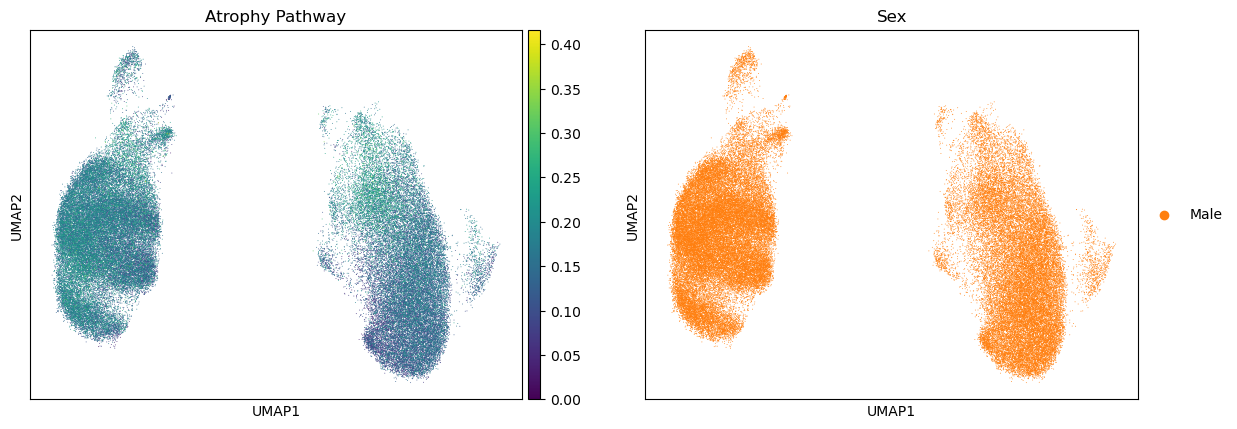

In [42]:
sc.pl.umap(adata_male, color=["Atrophy Pathway", 'Sex'])

In [43]:
# save adata
adata_male.write_h5ad(os.path.join(out_tmp, 'myofibers_male.h5ad'))

### Dotplot over all samples to show activities of multiple pathways

In [ ]:
def plot_pathway_dotplot_by_age(
    df_cell_level,
    score_cols, # List of pathway score column names
    age_col='age',
    sample_col='sample',
    annotation_col='Annotation',
    target_annotation=None,
    figsize=(10, 6),
    min_dot_size=20,
    max_dot_size=500,
    dot_size_scale_factor=1.0, # Adjust if sizes are too uniform or too varied
    cmap_name="coolwarm", # Or "RdYlBu_r" to mimic your example more closely
    value_legend_title="Mean Score",
    size_legend_title="# Cells"
):
    """
    Plots a dot plot where dot color is mean pathway score and dot size is number of cells.
    Samples are on x-axis ordered by age, pathways on y-axis.

    Parameters:
        df_cell_level (pd.DataFrame): Cell-level data with scores, age, sample, annotation.
        score_cols (list): List of score column names (pathways).
        age_col (str): Column name for age.
        sample_col (str): Column name for sample IDs.
        annotation_col (str): Column name for annotations.
        target_annotation (str or None): If provided, subset to this annotation.
        figsize (tuple): Figure size.
        min_dot_size (int): Minimum size for dots.
        max_dot_size (int): Maximum size for dots.
        dot_size_scale_factor (float): Multiplier for raw cell counts before scaling to dot size.
        cmap_name (str): Colormap for the scores.
        value_legend_title (str): Title for the colorbar.
        size_legend_title (str): Title for the size legend.
    """
    plot_df = df_cell_level.copy()

    # 1. Data Preparation
    if target_annotation is not None:
        if annotation_col not in plot_df.columns:
            print(f"Warning: Annotation column '{annotation_col}' not found. Cannot filter by '{target_annotation}'.")
            return
        plot_df = plot_df[plot_df[annotation_col] == target_annotation]
        if plot_df.empty:
            print(f"No cells found for annotation '{target_annotation}'.")
            return

    required_cols = [age_col, sample_col, annotation_col] + score_cols
    for col in required_cols:
        if col not in plot_df.columns:
            print(f"Warning: Required column '{col}' not found. Aborting.")
            return

    plot_df = plot_df.dropna(subset=[age_col, sample_col], how='any')
    if plot_df.empty:
        print("No data to plot after initial NaN filtering.")
        return

    # Aggregate: mean scores and cell counts
    grouped = plot_df.groupby(sample_col)
    mean_scores_df = grouped[score_cols].mean()
    cell_counts_series = grouped.size()
    sample_ages_series = grouped[age_col].mean() # Assuming age is consistent per sample

    # Order samples by age
    ordered_samples = sample_ages_series.sort_values().index.tolist()
    if not ordered_samples:
        print("Could not determine sample order.")
        return

    # Prepare data for plotting (long format)
    plot_data_list = []
    for sample_id in ordered_samples:
        for pathway in score_cols:
            mean_score = mean_scores_df.loc[sample_id, pathway] if sample_id in mean_scores_df.index else np.nan
            cell_count = cell_counts_series.loc[sample_id] if sample_id in cell_counts_series.index else 0
            age = sample_ages_series.loc[sample_id] if sample_id in sample_ages_series.index else np.nan
            plot_data_list.append({
                'sample': sample_id,
                'pathway': pathway,
                'mean_score': mean_score,
                'cell_count': cell_count,
                'age': age
            })
    plot_data_df = pd.DataFrame(plot_data_list)
    plot_data_df = plot_data_df.dropna(subset=['mean_score']) # Drop if score couldn't be calculated

    if plot_data_df.empty:
        print("No data to plot after aggregation.")
        return

    # Scale cell counts for dot sizes
    min_count = plot_data_df['cell_count'].min()
    max_count = plot_data_df['cell_count'].max()
    if max_count == min_count : # Avoid division by zero if all counts are the same
         plot_data_df['dot_size'] = min_dot_size if max_count == 0 else (min_dot_size + max_dot_size) / 2
    else:
        # Apply scale factor first
        scaled_counts = plot_data_df['cell_count'] * dot_size_scale_factor
        # Then normalize and scale to dot size range
        # Handle cases where scaled_counts might still be uniform after scaling factor
        min_s_count = scaled_counts.min()
        max_s_count = scaled_counts.max()
        if max_s_count == min_s_count:
             plot_data_df['dot_size'] = min_dot_size if max_s_count == 0 else (min_dot_size + max_dot_size) / 2
        else:
            plot_data_df['dot_size'] = min_dot_size + \
                (scaled_counts - min_s_count) / (max_s_count - min_s_count) * (max_dot_size - min_dot_size)


    # 2. Plotting
    fig, ax = plt.subplots(figsize=figsize)

    # Get unique pathway names for y-axis (preserve order from score_cols)
    pathway_names = score_cols
    pathway_y_coords = {name: i for i, name in enumerate(pathway_names)}

    # Get unique sample names for x-axis (already ordered by age)
    sample_x_coords = {name: i for i, name in enumerate(ordered_samples)}

    scatter = ax.scatter(
        x=plot_data_df['sample'].map(sample_x_coords),
        y=plot_data_df['pathway'].map(pathway_y_coords),
        s=plot_data_df['dot_size'],
        c=plot_data_df['mean_score'],
        cmap=cmap_name,
        edgecolors='gray', # Optional: add edge to dots
        linewidths=0.5    # Optional: edge width
    )

    # --- X-axis (Samples) ---
    ax.set_xticks(list(sample_x_coords.values()))
    ax.set_xticklabels(ordered_samples, rotation=45, ha="right")
    ax.set_xlabel("Sample (Ordered by Age)")

    # --- Age annotations on top ---
    ax2 = ax.twiny() # Create a second x-axis sharing the y-axis
    ax2.set_xlim(ax.get_xlim()) # Ensure limits match
    ax2.set_xticks(list(sample_x_coords.values()))
    ax2.set_xticklabels([f"{sample_ages_series[s]:.0f}" for s in ordered_samples], rotation=45, ha="left")
    ax2.set_xlabel("Age")

    # --- Y-axis (Pathways) ---
    ax.set_yticks(list(pathway_y_coords.values()))
    # Clean up pathway names for display
    #clean_pathway_names = [p.replace('KEGG_', '').replace('GOBP_', '').replace('REACTOME_', '').replace('_', ' ').title() for p in pathway_names]
    ax.set_yticklabels(pathway_names)
    ax.set_ylabel("DNA Damage and Repair Pathway")

    # --- Colorbar for Mean Score ---
    cbar = fig.colorbar(scatter, ax=ax, fraction=0.03, pad=0.15) # Adjust fraction and pad
    cbar.set_label(value_legend_title)

    # --- Legend for Dot Size (# Cells) ---
    # Create some proxy artists for the legend
    # Define some representative cell counts for the legend
    if max_count > 0 :
        legend_counts_raw = np.linspace(min_count, max_count, num=4, dtype=int)
        # Ensure 0 is included if min_count is 0 and it's meaningful
        if min_count == 0 and 0 not in legend_counts_raw and len(legend_counts_raw) > 1:
            legend_counts_raw[0] = 0
        legend_counts_raw = np.unique(legend_counts_raw) # Ensure unique values
    else: # Handle case where all counts are 0 or only one value
        legend_counts_raw = np.array([min_count]) if min_count > 0 else np.array([0])


    legend_dots = []
    legend_labels = []
    for count_val in legend_counts_raw:
        if max_count == min_count:
            size_val = min_dot_size if max_count == 0 else (min_dot_size + max_dot_size) / 2
        else:
            scaled_c = count_val * dot_size_scale_factor
            size_val = min_dot_size + \
                       (scaled_c - (min_count*dot_size_scale_factor)) / ((max_count*dot_size_scale_factor) - (min_count*dot_size_scale_factor)) * (max_dot_size - min_dot_size)
        size_val = max(min_dot_size, min(max_dot_size, size_val)) # Ensure it's within bounds

        legend_dots.append(plt.scatter([], [], s=size_val, c='gray', label=f"{int(count_val)}")) # Use gray for legend dots
        #legend_labels.append(f"{int(count_val)}") # No need, label is in scatter call

    # Position the size legend to the right, below the colorbar
    # The legend function needs handles and labels. We just pass the handles.
    size_leg = ax.legend(handles=legend_dots, title=size_legend_title,
                         bbox_to_anchor=(1.18, 0.4), loc='center left', # Adjust bbox_to_anchor
                         labelspacing=1.5, borderpad=1, frameon=True,
                         handletextpad=1.5, # Increase spacing between dot and text
                         scatterpoints=1) # Ensure only one dot per legend item

    # Adjust layout
    fig_title = f'Pathway Activity Dot Plot (Annotation: {target_annotation})' if target_annotation else 'Pathway Activity Dot Plot'
    plt.suptitle(fig_title, fontsize=16, y=1.05)
    plt.subplots_adjust(top=0.85, bottom=0.15, right=0.8) # Adjust subplot to make space for legends/title
    plt.grid(True, linestyle='--', alpha=0.5, axis='y') # Add y-axis grid
    ax.tick_params(axis='both', which='major', pad=7)
    ax2.tick_params(axis='x', which='major', pad=7)

    plt.show()

In [ ]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = adata_male.obs[['sample', 'age', 'Annotation'] + dna_damage_and_repair_pathways].copy()
plot_pathway_dotplot_by_age(
    df_cell_level=cell_level_scores_df, # Your cell-level data
    score_cols=dna_damage_and_repair_pathways,      # List of pathway score columns
    age_col='age',
    sample_col='sample',
    annotation_col='Annotation',
    target_annotation='Type II',         # Or whichever annotation you want
    figsize=(12, 7),                    # Adjust figure size
    min_dot_size=30,
    max_dot_size=600,
    dot_size_scale_factor=0.1, # YOU WILL LIKELY NEED TO TUNE THIS FACTOR!
                               # If cell counts are very large (e.g., 1000s),
                               # this factor should be small (e.g., 0.01, 0.1).
                               # If cell counts are small (e.g., 10s, 100s),
                               # this factor can be larger (e.g., 1.0, 5.0).
                               # The goal is to get a good visual spread of dot sizes.
    cmap_name="RdYlBu_r",               # Red-Yellow-Blue rseversed, hot is red
    value_legend_title="Mean Pathway Score",
    size_legend_title="# Cells in Sample"
)

# Downsample myofibers to include size matched old and young cohorts (n=2)

In [8]:
adata_male_downsampled = adata_male[adata_male.obs['sample'].isin(['P5', 'P13', 'OM5', 'OM7'])].copy()

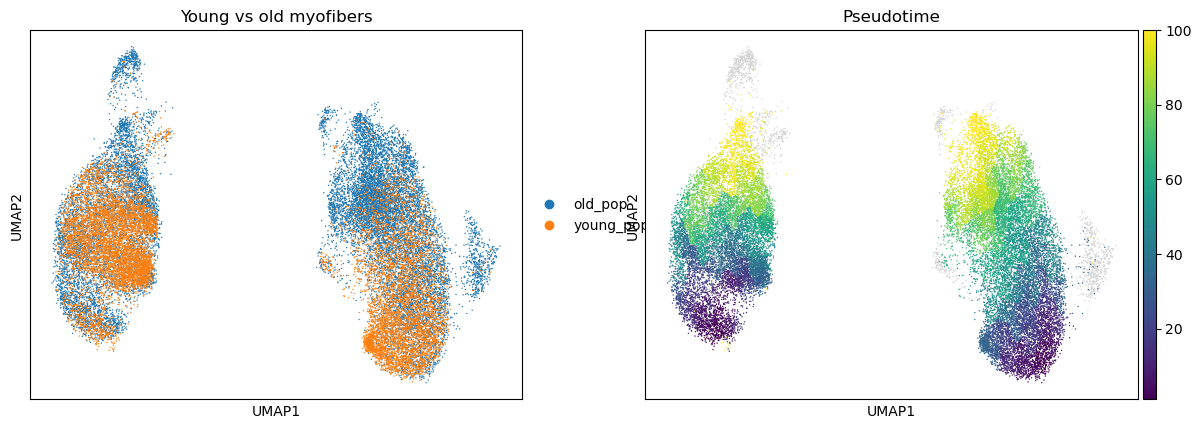

In [9]:
sc.pl.umap(adata_male_downsampled, color=['age_pop','Pseudotime'], title='Young vs old myofibers')

In [12]:
# get a df of sample ID, sample score per cell type and age
sample_scores = adata_male_downsampled.obs[['sample','age', 'Annotation']+ dna_damage_and_repair_pathways].copy()
# average scores per sample and group by Annotation
sample_scores_avg = sample_scores.groupby(['sample', 'Annotation']).mean().reset_index()
sample_scores_avg.head()

/tmp/ipykernel_101622/2821560851.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_scores_avg = sample_scores.groupby(['sample', 'Annotation']).mean().reset_index()


,sample,Annotation,age,DNA_DAMAGE_CHECKPOINT,GOBP_DNA_DAMAGE_RESPONSE,GOBP_DNA_REPAIR,HALLMARK_DNA_REPAIR,REACTOME_DNA_REPAIR,REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS
0,OM5,Type I,82.0,0.086170,0.085863,0.075171,0.047286,0.062263,0.071091
1,OM5,Type II,82.0,0.069601,0.083622,0.073094,0.046043,0.061196,0.074343
2,OM5,DCLK1+ (I),82.0,0.080726,0.086028,0.074641,0.049982,0.061964,0.071880
3,OM5,DCLK1+ (II),82.0,0.069796,0.084111,0.073417,0.048758,0.061505,0.071703
4,OM5,ENOX1+ (II),82.0,0.072478,0.084562,0.073562,0.046654,0.061638,0.071428


In [19]:
import matplotlib.pyplot as plt

def plot_multi_score_lines(
    df, 
    score_cols, 
    age_col='age', 
    sample_col='sample', 
    annotation=None, 
    figsize=(14, 7)
):
    """
    Plots multiple scores as colored lines with sample dots, ordered by age.
    
    Parameters:
        df (pd.DataFrame): Input dataframe.
        score_cols (list): List of score column names to plot.
        age_col (str): Column name for age (x-axis).
        sample_col (str): Column name for sample IDs (for labeling).
        annotation (str or None): If provided, subset to this annotation.
        figsize (tuple): Figure size.
    """
    # Optionally subset by annotation
    if annotation is not None:
        df = df[df['Annotation'] == annotation]
    
    # Drop rows with missing age or all scores missing
    df = df.dropna(subset=[age_col] + score_cols)
    # Sort by age
    df = df.sort_values(age_col)
    
    plt.figure(figsize=figsize)
    colors = plt.cm.tab10.colors  # Up to 10 distinct colors
    
    for i, score in enumerate(score_cols):
        y = df[score]
        x = df[age_col]
        plt.plot(x, y, label=score.replace('_', ' '), color=colors[i % len(colors)], marker='o')
        # Optionally, annotate with sample names
        for xi, yi, sample in zip(x, y, df[sample_col]):
            plt.annotate(
                sample, 
                (xi, yi), 
                color=colors[i % len(colors)], 
                fontsize=8, 
                xytext=(0, 5), 
                textcoords="offset points", 
                ha="center"
            )
    
    plt.xlabel('Age')
    plt.ylabel('Score')
    plt.title('Multiple DNA Damage/Repair Scores by Age' + (f' (Annotation: {annotation})' if annotation else ''))
    plt.legend(title='Score')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_multi_score_lines_by_pseudotime( # Renamed for clarity
    df_with_scores_and_pseudotime, # This df should have scores AND mean_pseudotime per sample
    score_cols,
    pseudotime_col='mean_pseudotime', # Column for mean pseudotime of the sample
    sample_col='sample',
    age_col_for_labeling='age', # Optional: still use original age for point labels if desired
    annotation=None,
    figsize=(14, 7)
):
    """
    Plots multiple scores as colored lines with sample dots, ordered by mean sample pseudotime.

    Parameters:
        df_with_scores_and_pseudotime (pd.DataFrame): Input dataframe with scores and mean_pseudotime.
        score_cols (list): List of score column names to plot.
        pseudotime_col (str): Column name for mean pseudotime (x-axis).
        sample_col (str): Column name for sample IDs (for labeling points).
        age_col_for_labeling (str or None): Original age column, if you want to include age in point labels.
        annotation (str or None): If provided, subset to this annotation.
        figsize (tuple): Figure size.
    """
    plot_df = df_with_scores_and_pseudotime.copy()

    # Optionally subset by annotation (if 'Annotation' column exists in this df)
    if annotation is not None and 'Annotation' in plot_df.columns:
        plot_df = plot_df[plot_df['Annotation'] == annotation]
    elif annotation is not None and 'Annotation' not in plot_df.columns:
        print(f"Warning: Annotation column not found in DataFrame, cannot filter by '{annotation}'.")


    # Drop rows with missing pseudotime or all scores missing
    # Ensure pseudotime_col is present
    if pseudotime_col not in plot_df.columns:
        print(f"Error: Pseudotime column '{pseudotime_col}' not found in DataFrame.")
        return
    plot_df = plot_df.dropna(subset=[pseudotime_col] + score_cols, how='any') # Drop if pseudotime or any score is NA

    if plot_df.empty:
        print("No data to plot after dropping NaNs.")
        return

    # Sort by the pseudotime column
    plot_df = plot_df.sort_values(pseudotime_col)

    plt.figure(figsize=figsize)
    colors = plt.cm.tab10.colors

    for i, score in enumerate(score_cols):
        if score not in plot_df.columns:
            print(f"Warning: Score column '{score}' not found. Skipping.")
            continue
        y = plot_df[score]
        x = plot_df[pseudotime_col] # Use pseudotime for x-axis

        plt.plot(x, y, label=score.replace('_', ' '), color=colors[i % len(colors)], marker='o')

        # Annotate with sample names (and optionally age)
        for idx, row in plot_df.iterrows():
            xi = row[pseudotime_col]
            yi = row[score]
            sample_name = row[sample_col]
            label_text = sample_name
            if age_col_for_labeling and age_col_for_labeling in row:
                age_val = row[age_col_for_labeling]
                if pd.notna(age_val):
                    label_text += f" (Age:{int(age_val)})" # Add age to the label

            plt.annotate(
                label_text,
                (xi, yi),
                color=colors[i % len(colors)],
                fontsize=8,
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom"
            )

    plt.xlabel(f'Mean Sample {pseudotime_col.replace("_", " ").title()}') # Updated x-axis label
    plt.ylabel('Pathway Score')
    title = 'Pathway Scores by Mean Sample Pseudotime'
    if annotation:
        title += f' (Annotation: {annotation})'
    plt.title(title)
    plt.legend(title='Pathway Score')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Line plot of scores wrt age

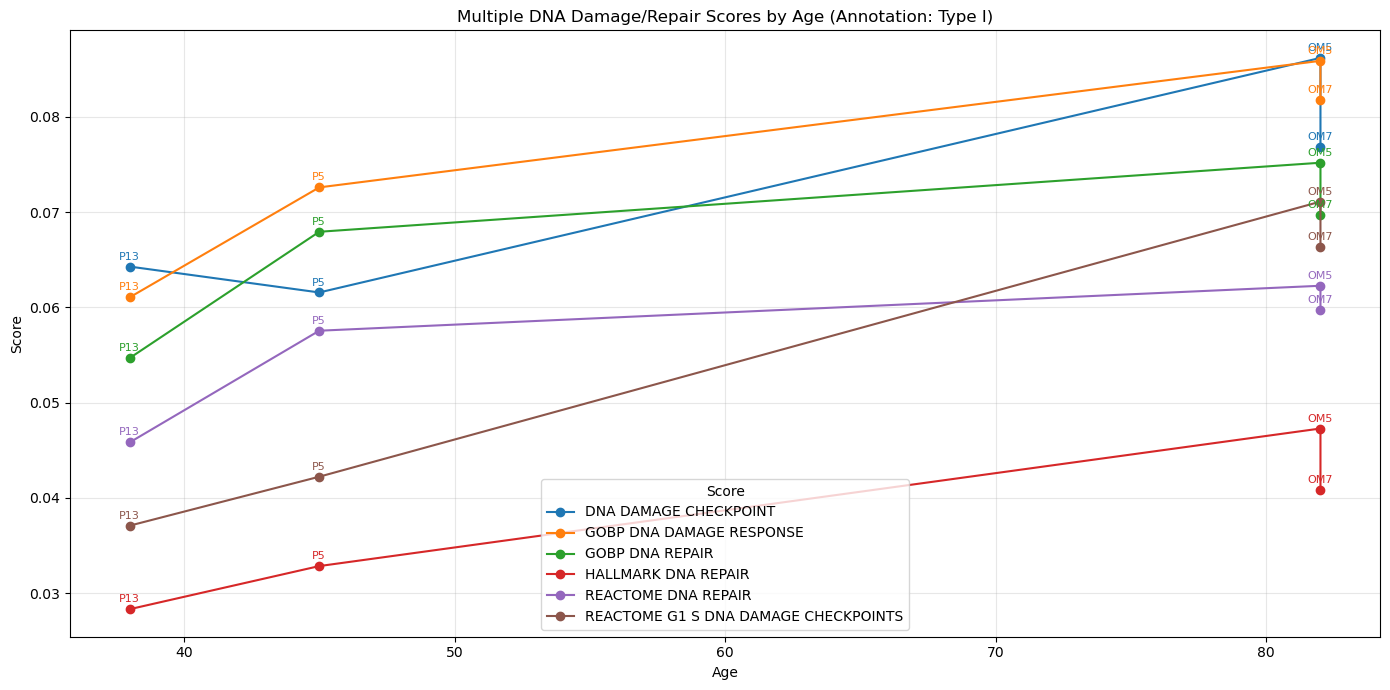

In [20]:
plot_multi_score_lines(
    sample_scores_avg,
    dna_damage_and_repair_pathways,
    age_col='age',
    sample_col='sample',
    annotation='Type I'
)

#### Line plot of scores wrt pseudotime

In [14]:
obs_df = adata_male_downsampled.obs[['sample', 'age', 'Annotation', 'Pseudotime']].copy()
obs_df_valid_pt = obs_df.dropna(subset=['Pseudotime'])

/tmp/ipykernel_101622/3170577424.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_pseudotime_summary = obs_df_valid_pt.groupby(['sample', 'Annotation']).agg( # or just ['sample']


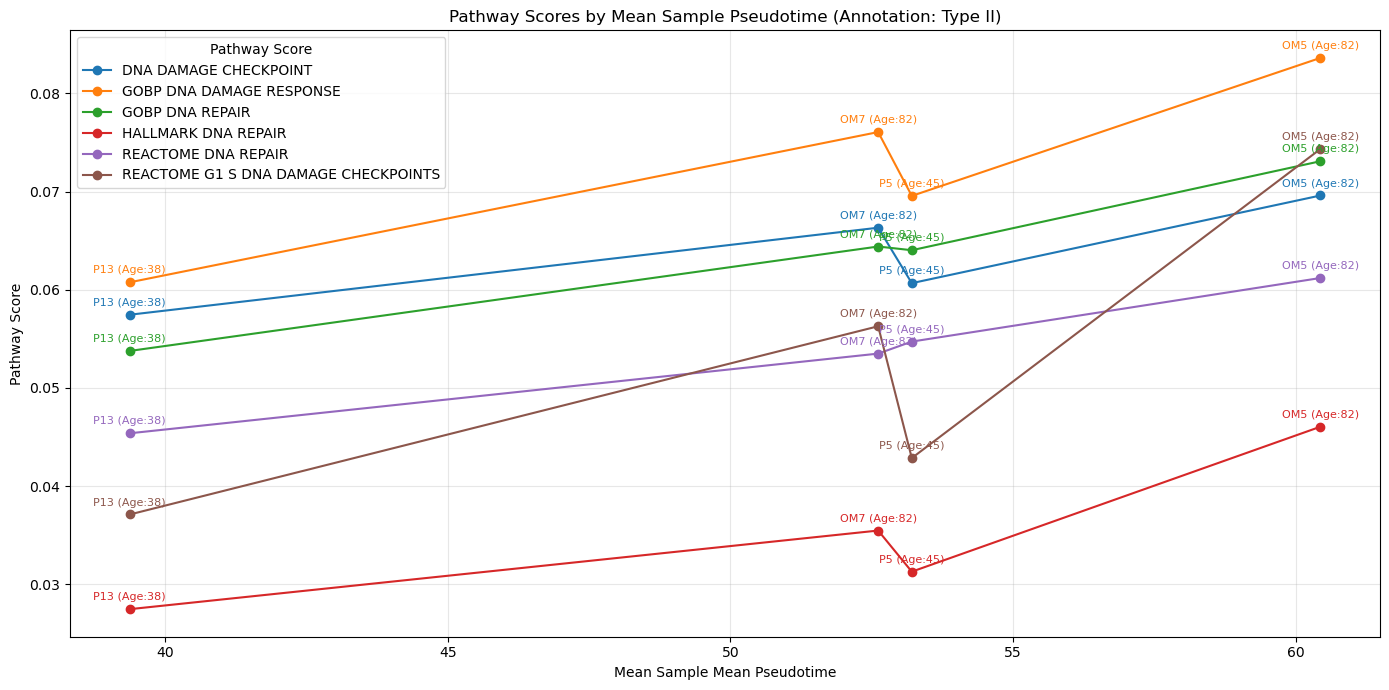

In [21]:
if obs_df_valid_pt.empty:
    print("No cells with valid pseudotime values. Cannot calculate mean pseudotime.")
else:
    # Group by sample AND Annotation if you want means specific to that combination
    # Or just by sample if pseudotime should be an overall sample average
    sample_pseudotime_summary = obs_df_valid_pt.groupby(['sample', 'Annotation']).agg( # or just ['sample']
        mean_pseudotime=('Pseudotime', 'mean'),
        age=('age', 'first') # Keep original age
    ).reset_index()

    # Now merge the mean_pseudotime into this pathway score DataFrame
    df_for_plot = pd.merge(
        sample_scores_avg, # Your DataFrame with averaged pathway scores
        sample_pseudotime_summary[['sample', 'Annotation', 'mean_pseudotime']], # Only need these columns for merging
        on=['sample', 'Annotation'], # Merge keys
        how='left' # Use 'left' to keep all pathway score rows
    )

    if 'mean_pseudotime' not in df_for_plot.columns or df_for_plot['mean_pseudotime'].isnull().all():
        print("Merging failed or no mean_pseudotime values available. Check your dataframes.")
    else:
        # --- Call the plotting function ---
        plot_multi_score_lines_by_pseudotime(
            df_with_scores_and_pseudotime=df_for_plot,
            score_cols=dna_damage_and_repair_pathways, # Your list of pathway score columns
            pseudotime_col='mean_pseudotime',
            sample_col='sample',
            age_col_for_labeling='age', # Will show sample name and original age
            annotation='Type II' # Or your desired annotation, or None
        )

#### Box plots of scores per cell wrt age

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

def plot_pathway_box_distributions_by_age( # Renamed for clarity
    df_cell_level,
    score_cols,
    geneset_sizes,
    age_col='age',
    sample_col='sample',
    annotation_col='Annotation',
    target_annotation=None,
    filter_quantile_to_keep_top=None,
    n_subplot_cols=2,
    figsize_per_subplot=(8, 6),
    box_width=0.8, # Control width of boxes
    sample_label_fontsize=8,
    sample_label_y_offset_factor=0.05
):
    """
    Plots box plots for multiple pathway scores, with samples positioned by age on x-axis.
    Sample IDs are annotated above the boxes.
    Optionally filters cells to keep only the most active ones per sample per pathway.

    Parameters:
        df_cell_level (pd.DataFrame): Cell-level data.
        score_cols (list): List of score column names to plot.
        geneset_sizes (pd.Series or dict): Maps score_col names to their sizes.
        age_col (str): Column name for age.
        sample_col (str): Column name for sample IDs.
        annotation_col (str): Column name for annotations.
        target_annotation (str or None): If provided, subset to this annotation.
        filter_quantile_to_keep_top (float or None): Quantile of top scores to keep.
        n_subplot_cols (int): Number of columns in the subplot grid.
        figsize_per_subplot (tuple): Figure size for each individual subplot.
        box_width (float): Width of the box plots.
        sample_label_fontsize (int): Fontsize for sample ID labels.
        sample_label_y_offset_factor (float): Factor to adjust y-position of sample labels.
    """
    plot_df = df_cell_level.copy()

    if target_annotation is not None:
        if annotation_col not in plot_df.columns:
            print(f"Warning: Annotation column '{annotation_col}' not found. Cannot filter by '{target_annotation}'.")
            return
        plot_df = plot_df[plot_df[annotation_col] == target_annotation]
        if plot_df.empty:
            print(f"No cells found for annotation '{target_annotation}'.")
            return

    required_cols = [age_col, sample_col] + score_cols
    for col in required_cols:
        if col not in plot_df.columns:
            print(f"Warning: Required column '{col}' not found. Aborting.")
            return

    plot_df = plot_df.dropna(subset=[age_col, sample_col], how='any')
    plot_df = plot_df.dropna(subset=score_cols, how='all')

    if plot_df.empty:
        print("No data to plot after initial NaN filtering.")
        return

    unique_ages_sorted = sorted(plot_df[age_col].unique())
    age_to_xpos = {age: i for i, age in enumerate(unique_ages_sorted)}
    plot_df['x_position'] = plot_df[age_col].map(age_to_xpos)

    xpos_to_samples = plot_df.groupby('x_position')[sample_col].unique().apply(lambda x: '/'.join(sorted(x)))


    num_scores = len(score_cols)
    n_subplot_rows = (num_scores + n_subplot_cols - 1) // n_subplot_cols

    fig, axes = plt.subplots(
        n_subplot_rows,
        n_subplot_cols,
        figsize=(figsize_per_subplot[0] * n_subplot_cols, figsize_per_subplot[1] * n_subplot_rows),
        squeeze=False
    )
    axes = axes.flatten()

    for i, score in enumerate(score_cols):
        ax = axes[i]
        current_score_df = plot_df[['x_position', sample_col, age_col, score]].copy().dropna(subset=[score])

        if current_score_df.empty:
            ax.set_title(f"{score.replace('_', ' ')}\n(No data)")
            ax.axis('off')
            continue

        df_for_plot = current_score_df.copy()

        if filter_quantile_to_keep_top is not None and 0 < filter_quantile_to_keep_top < 1:
            quantile_for_threshold = 1.0 - filter_quantile_to_keep_top
            def filter_by_quantile(group):
                if group.empty or len(group) < 2:
                    return group
                original_sample_group = plot_df[
                    (plot_df[sample_col] == group[sample_col].iloc[0]) &
                    (plot_df[age_col] == group[age_col].iloc[0])
                ][score]
                if original_sample_group.empty or len(original_sample_group) < 2:
                    return group
                threshold_val = original_sample_group.quantile(quantile_for_threshold)
                return group[group[score] >= threshold_val]
            df_for_plot = df_for_plot.groupby([sample_col, age_col], group_keys=False).apply(filter_by_quantile)

            if df_for_plot.empty:
                ax.set_title(f"{score.replace('_', ' ')}\n(No data after filtering)")
                ax.axis('off')
                continue
        
        # --- Changed from violinplot to boxplot ---
        sns.boxplot(x='x_position', y=score, data=df_for_plot, ax=ax, palette="tab10", width=box_width, fliersize=2) # fliersize controls outlier point size

        ax.set_xticks(list(age_to_xpos.values()))
        ax.set_xticklabels([str(int(ua)) if ua==int(ua) else str(round(ua,1)) for ua in unique_ages_sorted], rotation=45, ha="right")
        ax.set_xlabel('Age')

        # Annotate sample IDs above boxes
        # Determine y-position for labels based on existing data in the current plot
        if not df_for_plot.empty:
            # Consider whisker ends for max y to place labels above.
            # Boxplot calculations for whiskers can be complex, so we take a simpler approach:
            # Use the max data point within 1.5*IQR or the absolute max if no outliers,
            # or simply the max of the data points plotted.
            # A robust way is to find the top of the whiskers if possible, or just use max data for simplicity.
            y_values_in_plot = []
            for x_pos_val in df_for_plot['x_position'].unique():
                y_values_in_plot.extend(df_for_plot[df_for_plot['x_position'] == x_pos_val][score])
            
            if y_values_in_plot:
                max_y_val_for_labeling = np.percentile(y_values_in_plot, 99) # Use 99th percentile to avoid extreme outliers influencing label position too much
                min_y_val_for_labeling = np.percentile(y_values_in_plot, 1)
                y_range = max_y_val_for_labeling - min_y_val_for_labeling
                y_offset = max_y_val_for_labeling + (y_range * sample_label_y_offset_factor) if y_range > 0 else max_y_val_for_labeling * (1 + sample_label_y_offset_factor*2)
            else: # Fallback if no data somehow
                y_offset = ax.get_ylim()[1] * 0.05 # Default offset if no data
        else:
            y_offset = ax.get_ylim()[1] * 0.05


        current_x_positions = sorted(df_for_plot['x_position'].unique())
        for x_pos in current_x_positions:
            sample_names_at_xpos = xpos_to_samples.get(x_pos, "")
            if sample_names_at_xpos:
                 ax.text(x_pos, y_offset, sample_names_at_xpos,
                        ha='center', va='bottom', fontsize=sample_label_fontsize, rotation=90)

        title_text = score.replace('_', ' ')
        size = geneset_sizes.get(score)
        if size is not None:
            title_text += f"\n(n={int(size)})"
        if filter_quantile_to_keep_top is not None:
            title_text += f"\n(Top {filter_quantile_to_keep_top*100:.0f}% cells per sample)"

        ax.set_title(title_text)
        ax.set_ylabel('Score Distribution')
        ax.grid(True, alpha=0.3, axis='y')

    for j in range(num_scores, len(axes)):
        axes[j].axis('off')

    fig_title = 'Pathway Score Distributions by Age'
    if target_annotation:
        fig_title += f' (Annotation: {target_annotation})'
    plt.suptitle(fig_title, fontsize=16, y=1.02 if n_subplot_rows > 1 else 1.05)

    plt.tight_layout(rect=[0, 0, 1, 0.98 if n_subplot_rows > 1 else 0.95])
    plt.show()

In [45]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = adata_male_downsampled.obs[['sample', 'age', 'Annotation', 'Pseudotime'] + dna_damage_and_repair_pathways].copy()
# geneset_sizes_data = {
#     'KEGG_OXIDATIVE_PHOSPHORYLATION': 132,
#     'GOBP_FATTY_ACID_BETA_OXIDATION': 75,
#     'KEGG_GLYCOLYSIS_GLUCONEOGENESIS': 62,
#     'KEGG_CITRATE_CYCLE_TCA_CYCLE': 31,
#     'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM': 21,
#     'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM': 14
# }
geneset_sizes_data = {
    'GOBP_DNA_DAMAGE_RESPONSE': 906,
    'GOBP_DNA_REPAIR': 615,
    'REACTOME_DNA_REPAIR': 332,
    'HALLMARK_DNA_REPAIR': 150,
    'REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS': 68,
    'DNA_DAMAGE_CHECKPOINT': 20
}
geneset_sizes_series = pd.Series(geneset_sizes_data)

# Your list of score columns
score_cols_to_plot = list(geneset_sizes_series.index)

/tmp/ipykernel_101622/286968175.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='x_position', y=score, data=df_for_plot, ax=ax, palette="tab10", width=box_width, fliersize=2) # fliersize controls outlier point size
/tmp/ipykernel_101622/286968175.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='x_position', y=score, data=df_for_plot, ax=ax, palette="tab10", width=box_width, fliersize=2) # fliersize controls outlier point size
/tmp/ipykernel_101622/286968175.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='x_position',

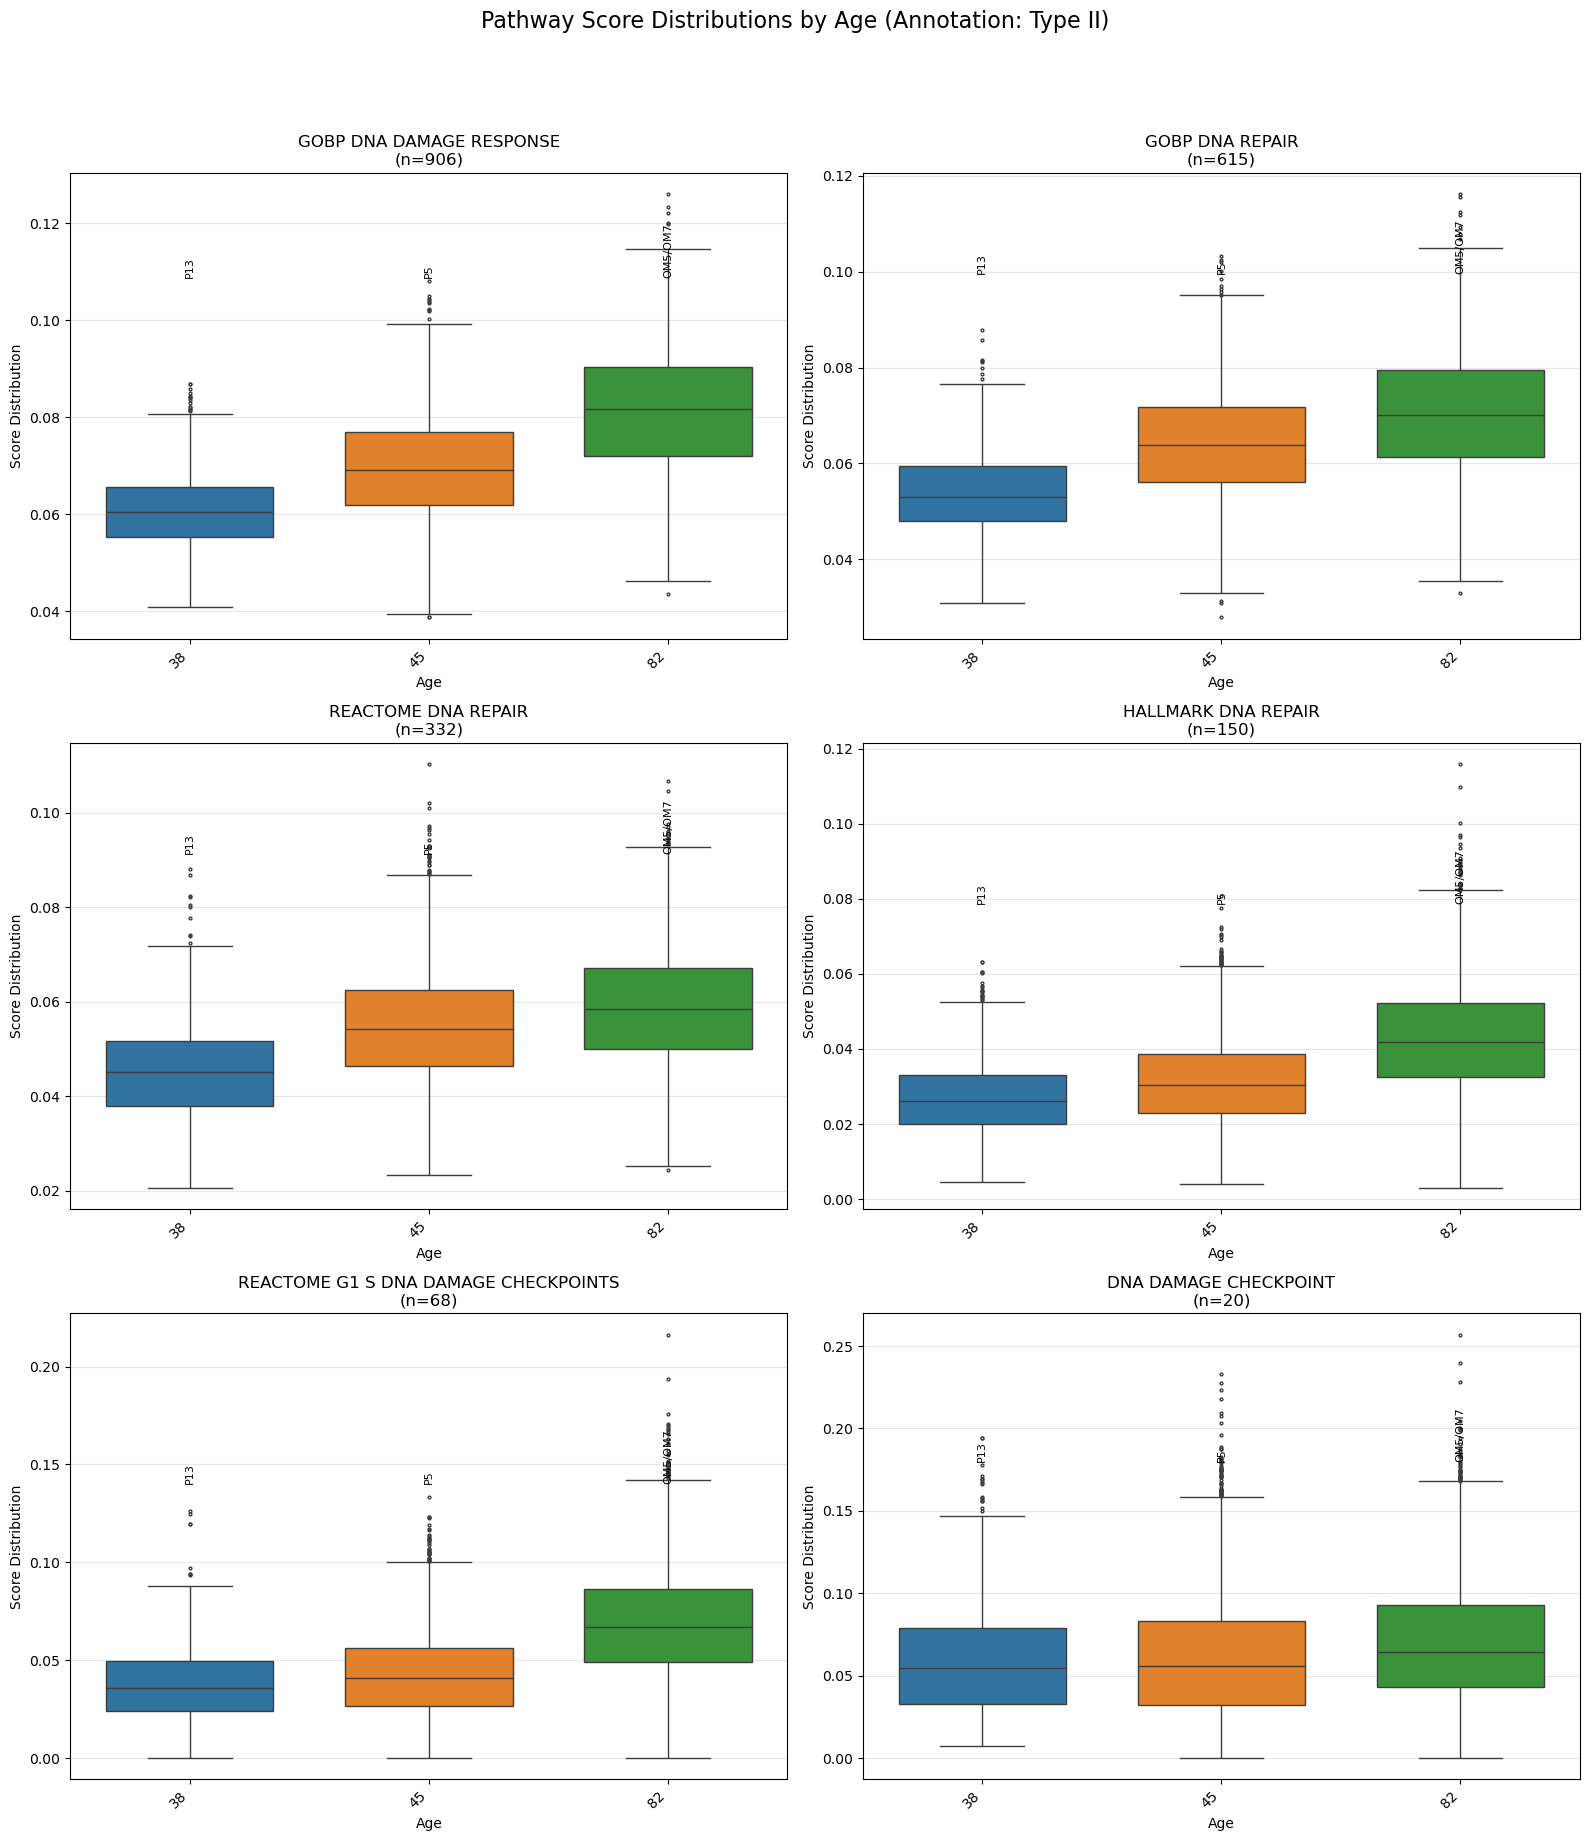

In [ ]:
plot_pathway_box_distributions_by_age( # Note the new function name
    df_cell_level=cell_level_scores_df,
    score_cols=score_cols_to_plot,
    geneset_sizes=geneset_sizes_series,
    age_col='age',
    sample_col='sample',
    annotation_col='Annotation',
    target_annotation='Type II', # Using 'Type I' as in your image example
    filter_quantile_to_keep_top=None, # or 0.75, etc.
    n_subplot_cols=2, # As in your image example
    box_width=0.7, # Adjust for aesthetics
    sample_label_y_offset_factor=0.08 # May need adjustment
)

#### Line plots per cell over pseudotime

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing
from statsmodels.nonparametric.smoothers_lowess import lowess # For LOWESS

def _df_plot_smoothed_group_lines_on_ax( # Unified helper
    ax,
    df_cell_level: pd.DataFrame,
    pathway_score_key: str,
    pseudotime_key: str,
    group_by_key: str,
    smoothing_method: str = None, # 'gaussian', 'lowess', or None/'' for raw
    smoothing_strength: float = None, # sigma for gaussian, frac for lowess
    geneset_size: int = None,
    groups_to_plot: list = None,
    colors_dict: dict = None,
    xlabel: str = "Pseudotime",
    ylabel: str = "Score",
    title_override: str = None,
    legend_labels: dict = None,
    legend_title: str = None,
    legend_loc: str = 'best',
    legend_frameon: bool = False,
    line_kwargs: dict = None,
    ylim: tuple = None,
    xticks_list: list = None,
    yticks_list: list = None,
    despine: bool = True,
    show_legend: bool = True,
    debug_prints: bool = False
):
    # --- Initial checks and data prep ---
    required_cols_for_plot = [pathway_score_key, pseudotime_key, group_by_key]
    for col in required_cols_for_plot:
        if col not in df_cell_level.columns:
            ax.set_title(f"{pathway_score_key.replace('_', ' ')}\n(Error: Column '{col}' missing)")
            ax.axis('off'); return False
    obs_df = df_cell_level[required_cols_for_plot].copy()
    obs_df.dropna(subset=required_cols_for_plot, inplace=True)
    subplot_title_text = title_override if title_override else pathway_score_key.replace('_', ' ')
    if geneset_size is not None: subplot_title_text += f"\n(n={int(geneset_size)})"
    if obs_df.empty:
        ax.set_title(f"{subplot_title_text}\n(No valid data after NA removal)")
        ax.axis('off'); return False
    obs_df[group_by_key] = obs_df[group_by_key].astype(str)
    if groups_to_plot is None: unique_groups_to_plot = sorted(obs_df[group_by_key].unique())
    else:
        groups_to_plot_str = [str(g) for g in groups_to_plot]
        available_groups_in_df = obs_df[group_by_key].unique()
        unique_groups_to_plot = [g for g in groups_to_plot_str if g in available_groups_in_df]
        if not unique_groups_to_plot:
            ax.set_title(f"{subplot_title_text}\n(Specified groups not found or no data)")
            ax.axis('off'); return False
    _default_colors = plt.cm.get_cmap('tab10').colors
    actual_line_kwargs = {'linewidth': 1.5};
    if line_kwargs: actual_line_kwargs.update(line_kwargs)
    plotted_anything_on_this_ax = False

    # --- Loop through groups and plot ---
    for i, group_name_str in enumerate(unique_groups_to_plot):
        group_df = obs_df[obs_df[group_by_key] == group_name_str]
        if group_df.empty:
            if debug_prints: print(f"D: Group '{group_name_str}' empty for '{pathway_score_key}'.")
            continue

        group_df_sorted = group_df.sort_values(by=pseudotime_key)
        x_vals = group_df_sorted[pseudotime_key].values.astype(float)
        y_vals_raw = group_df_sorted[pathway_score_key].values.astype(float)

        if len(x_vals) < 2:
            if debug_prints: print(f"D: <2 points for group '{group_name_str}', score '{pathway_score_key}'.")
            continue
        
        y_vals_to_plot = y_vals_raw
        x_vals_to_plot = x_vals

        # Apply smoothing if requested
        if smoothing_method and smoothing_strength is not None:
            if smoothing_method.lower() == 'gaussian':
                if len(y_vals_raw) > int(4 * smoothing_strength) and smoothing_strength > 0:
                    try: y_vals_to_plot = gaussian_filter1d(y_vals_raw, sigma=smoothing_strength)
                    except Exception as e:
                        if debug_prints: print(f"D: Gaussian smooth error for '{group_name_str}', '{pathway_score_key}': {e}. Using raw.")
                elif debug_prints: print(f"D: Not enough points for Gaussian (sigma={smoothing_strength}) for '{group_name_str}', '{pathway_score_key}'. Using raw.")
            
            elif smoothing_method.lower() == 'lowess':
                if len(x_vals) >= 3 and len(np.unique(x_vals)) >= 2 and 0 < smoothing_strength < 1:
                    try:
                        smoothed_points = lowess(y_vals_raw, x_vals, frac=smoothing_strength, is_sorted=True, return_sorted=True)
                        x_vals_to_plot = smoothed_points[:, 0]
                        y_vals_to_plot = smoothed_points[:, 1]
                    except Exception as e:
                        if debug_prints: print(f"D: LOWESS smooth error (frac={smoothing_strength}) for '{group_name_str}', '{pathway_score_key}': {e}. Using raw.")
                elif debug_prints: print(f"D: Not enough/suitable points for LOWESS (frac={smoothing_strength}) for '{group_name_str}', '{pathway_score_key}'. Using raw.")
            
            elif debug_prints: print(f"D: Unknown smoothing_method '{smoothing_method}' or invalid strength. Using raw.")
        elif smoothing_method and debug_prints : print(f"D: Smoothing method '{smoothing_method}' requested but strength is None. Using raw.")


        if debug_prints:
            print(f"D: Group '{group_name_str}', Score '{pathway_score_key}' (Method: {smoothing_method or 'raw'}, Strength: {smoothing_strength}):")
            print(f"  Plotting with x_vals count: {len(x_vals_to_plot)}")
            print(f"  Plotting with y_vals min/max: {np.nanmin(y_vals_to_plot):.4f}/{np.nanmax(y_vals_to_plot):.4f}")
            
        color_to_use = colors_dict.get(group_name_str, _default_colors[i % len(_default_colors)]) if colors_dict else _default_colors[i % len(_default_colors)]
        label_for_legend = legend_labels.get(group_name_str, group_name_str) if legend_labels else group_name_str
            
        ax.plot(x_vals_to_plot, y_vals_to_plot, label=label_for_legend, color=color_to_use, **actual_line_kwargs)
        plotted_anything_on_this_ax = True

    # --- Finalize subplot ---
    if not plotted_anything_on_this_ax:
        ax.set_title(f"{subplot_title_text}\n(No lines plotted)"); return False
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(subplot_title_text)
    if show_legend and unique_groups_to_plot:
        handles, labels = ax.get_legend_handles_labels()
        if handles: ax.legend(handles, labels, title=legend_title, loc=legend_loc, frameon=legend_frameon, fontsize='small')
    if ylim: ax.set_ylim(ylim)
    if xticks_list is not None: ax.set_xticks(xticks_list if xticks_list else [])
    if yticks_list is not None: ax.set_yticks(yticks_list if yticks_list else [])
    if despine:
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.5); ax.spines['bottom'].set_linewidth(1.5)
        ax.tick_params(width=1.5)
    return True


def plot_multi_smoothed_lines_from_df( # Unified main plotter
    df_cell_level: pd.DataFrame,
    score_cols: list,
    pseudotime_key: str,
    group_by_key: str,
    smoothing_method: str = None, # 'gaussian', 'lowess', or None
    smoothing_strength: float = None, # sigma or frac
    geneset_sizes: pd.Series = None,
    groups_to_plot: list = None, colors_dict: dict = None, legend_labels_map: dict = None,
    n_subplot_cols: int = 2, figsize_per_subplot: tuple = (7, 4),
    common_xlabel: str = r"Pseudotime $\rightarrow$", common_ylabel: str = "Score",
    common_ylim: tuple = None, common_xticks_list: list = None, common_yticks_list: list = None,
    common_legend_loc: str = (0.02, 0.85), common_legend_frameon: bool = False,
    common_line_kwargs: dict = None, despine_subplots: bool = True,
    main_figure_title: str = None, show_legend_in_each_subplot: bool = True,
    debug_prints_for_subp_plot_func: bool = False
):
    # --- Initial checks for main function ---
    num_scores = len(score_cols)
    if num_scores == 0: print("No score columns"); return
    required_df_cols = score_cols + [pseudotime_key, group_by_key]
    missing_cols = [col for col in required_df_cols if col not in df_cell_level.columns]
    if missing_cols: print(f"Missing columns: {missing_cols}"); return
    if smoothing_method and smoothing_method.lower() not in ['gaussian', 'lowess']:
        print(f"Warning: Unknown smoothing_method '{smoothing_method}'. Plotting raw lines.")
        smoothing_method = None # Default to raw if unknown

    # --- Setup subplots ---
    n_subplot_rows = (num_scores + n_subplot_cols - 1) // n_subplot_cols
    fig, axes = plt.subplots(n_subplot_rows, n_subplot_cols,
        figsize=(figsize_per_subplot[0] * n_subplot_cols, figsize_per_subplot[1] * n_subplot_rows),
        squeeze=False)
    axes = axes.flatten()

    # --- Loop and call helper ---
    for i, score_key_current in enumerate(score_cols):
        ax = axes[i]
        current_geneset_size = geneset_sizes.get(score_key_current) if geneset_sizes is not None else None
        _df_plot_smoothed_group_lines_on_ax(
            ax=ax, df_cell_level=df_cell_level, pathway_score_key=score_key_current,
            pseudotime_key=pseudotime_key, group_by_key=group_by_key,
            smoothing_method=smoothing_method, smoothing_strength=smoothing_strength,
            geneset_size=current_geneset_size, groups_to_plot=groups_to_plot,
            colors_dict=colors_dict, xlabel=common_xlabel, ylabel=common_ylabel,
            legend_labels=legend_labels_map, legend_loc=common_legend_loc,
            legend_frameon=common_legend_frameon, line_kwargs=common_line_kwargs,
            ylim=common_ylim, xticks_list=common_xticks_list, yticks_list=common_yticks_list,
            despine=despine_subplots, show_legend=show_legend_in_each_subplot,
            debug_prints=debug_prints_for_subp_plot_func
        )

    # --- Finalize figure ---
    for j in range(num_scores, len(axes)): axes[j].axis('off')
    if main_figure_title: fig.suptitle(main_figure_title, fontsize=16, y=1.02 if n_subplot_rows > 1 else 1.05)
    plt.tight_layout(rect=[0, 0, 1, 0.97 if main_figure_title and n_subplot_rows > 1 else 0.98])
    plt.show()

/tmp/ipykernel_101622/2263936671.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _default_colors = plt.cm.get_cmap('tab10').colors
/tmp/ipykernel_101622/2263936671.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _default_colors = plt.cm.get_cmap('tab10').colors
/tmp/ipykernel_101622/2263936671.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _default_colors = plt.cm.get_cmap('tab10').colors
/tmp/ipykernel_101622/2263936671.py:55: MatplotlibDeprecat

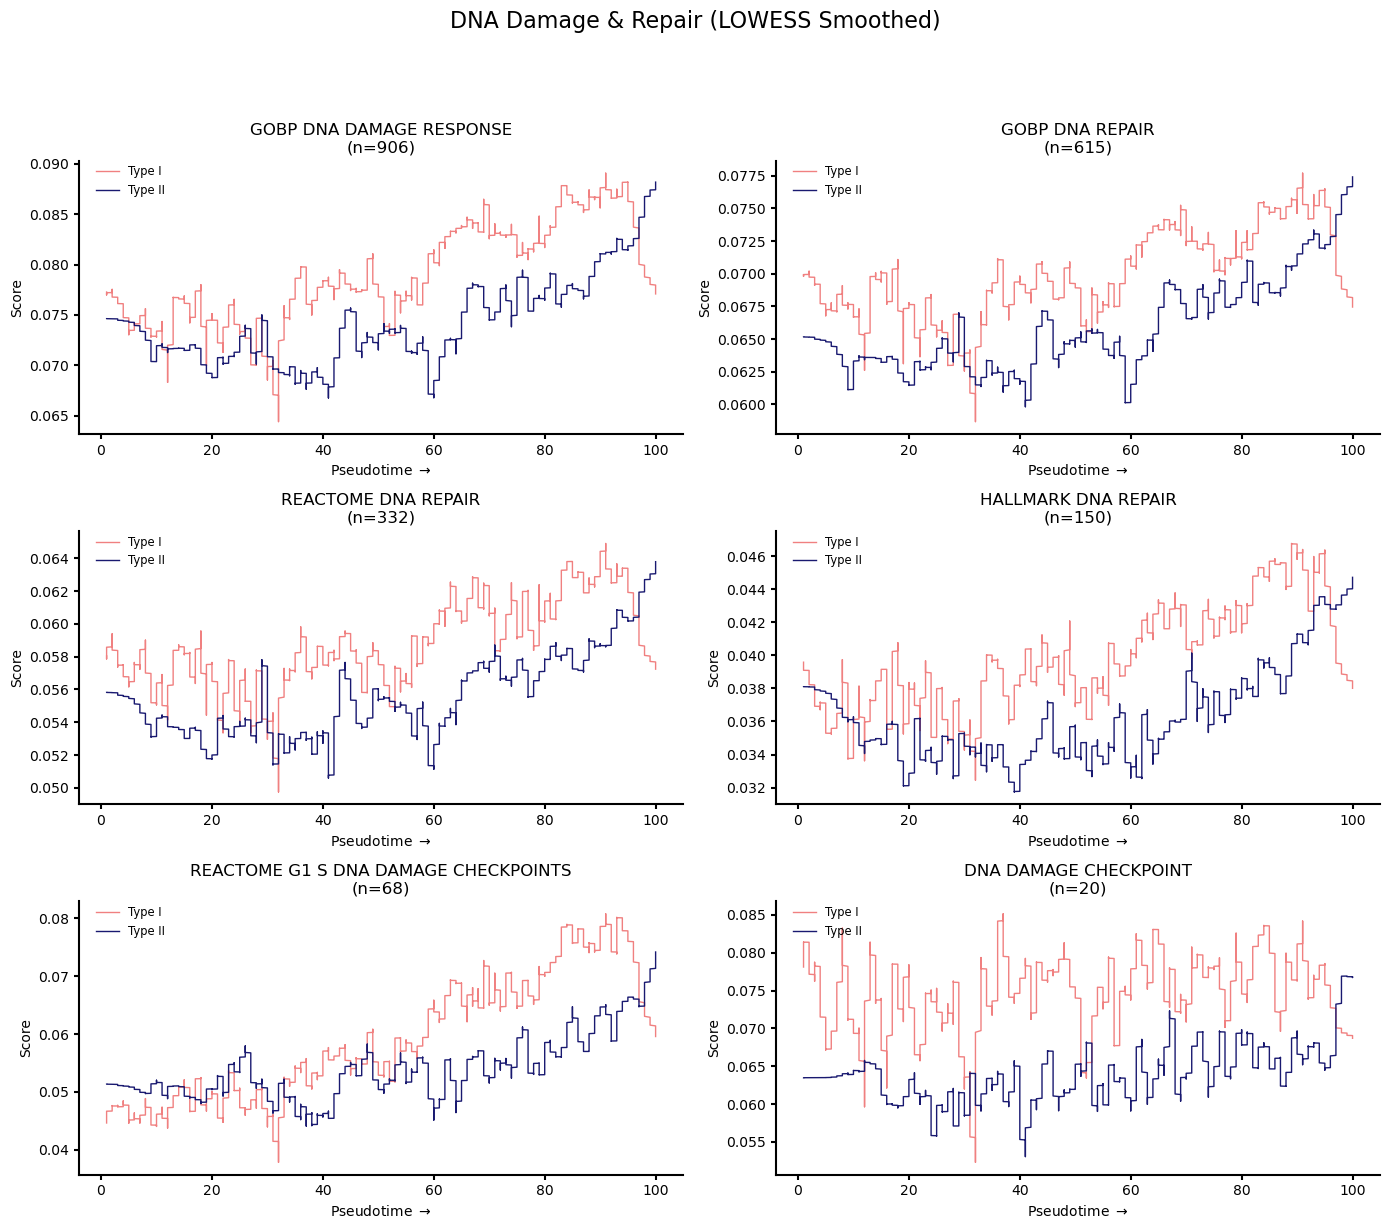

In [62]:
# Colors for 'Type I' and 'Type II'
plot_colors = {'Type I': '#F08080', 'Type II': '#191970'}
legend_labels = {'Type I': 'Type I', 'Type II': 'Type II'}

plot_multi_smoothed_lines_from_df(
    df_cell_level=cell_level_scores_df,
    score_cols=score_cols_to_plot,
    pseudotime_key='Pseudotime',
    group_by_key='Annotation',
    smoothing_method='gaussian',          # Specify method
    smoothing_strength=50.0,             # Fraction for LOWESS (e.g., 0.05 to 0.2)
    geneset_sizes=geneset_sizes_series,
    groups_to_plot=['Type I', 'Type II'],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    n_subplot_cols=2,
    figsize_per_subplot=(7, 4),
    common_xlabel=r"Pseudotime $\rightarrow$",
    common_ylabel="Score",
    common_ylim=None, common_xticks_list=None, common_yticks_list=None,
    common_legend_loc=(0.02, 0.85), common_line_kwargs={'linewidth': 1.0},
    main_figure_title="DNA Damage & Repair (LOWESS Smoothed)",
    debug_prints_for_subp_plot_func=False
)


# DEGs and gsea pathway analysis

#### Do size matching to get a more balanced sample size for DEG significance

In [63]:
adata_male_downsampled.obs['age_pop'] = pd.Categorical(adata_male_downsampled.obs['age_pop'], categories=["old_pop", "young_pop"], ordered=True)

In [64]:
bdata = adata_male_downsampled[adata_male_downsampled.obs.Annotation == "Type II"].copy()
bdata

AnnData object with n_obs × n_vars = 10230 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'GOBP_DNA_DAMAGE_RESPONSE', 'REACTOME_DNA_REPAIR', 'DNA_DAMAGE_CHECKPOINT', 'REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'GOBP_FATTY_ACID_BETA_OXIDATION', 'KEGG_CITRATE_CYCLE_TCA_CYCLE', 'KEGG_GLYCOLYSIS_GLUCONEOGENESIS', 'KEGG_OXIDATIVE_PHOSPHORYLATION', 'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM', 'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM', 'Atrophy Pathway'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'Sex_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors

In [65]:
sc.tl.rank_genes_groups(bdata,
                        groupby='age_pop',
                        use_raw=False,
                        method='wilcoxon',
                        groups=["old_pop"],
                        reference='young_pop')

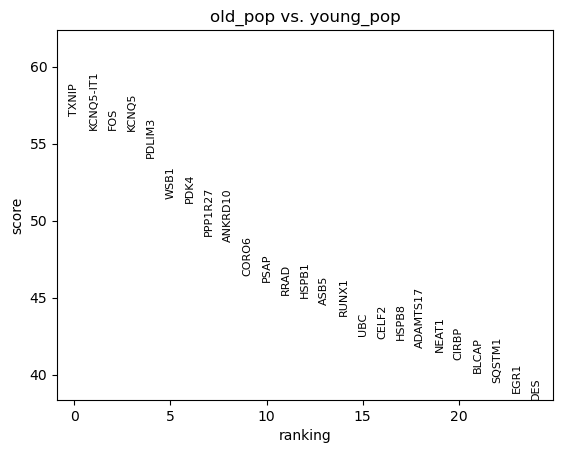

In [66]:
sc.pl.rank_genes_groups(bdata, n_genes=25, sharey=False)

In [67]:
# get deg result
result = bdata.uns['rank_genes_groups']
groups = result['names'].dtype.names
degs = pd.DataFrame(
    {group + '_' + key: result[key][group]
    for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
degs.head()

,old_pop_names,old_pop_scores,old_pop_pvals,old_pop_pvals_adj,old_pop_logfoldchanges
0,TXNIP,56.832657,0.0,0.0,3.633598
1,KCNQ5-IT1,55.916389,0.0,0.0,3.065933
2,FOS,55.871655,0.0,0.0,12.237828
3,KCNQ5,55.863853,0.0,0.0,1.968955
4,PDLIM3,54.107647,0.0,0.0,2.427506


In [68]:
# subset up or down regulated genes
degs_sig = degs[degs.old_pop_pvals_adj < 0.01]
degs_up = degs_sig[degs_sig.old_pop_logfoldchanges > 0]
degs_dw = degs_sig[degs_sig.old_pop_logfoldchanges < 0]

In [69]:
degs_up.shape

(4059, 5)

In [70]:
degs_dw.shape

(797, 5)

In [71]:
enr_up = gp.enrichr(degs_up.old_pop_names,
                    gene_sets='GO_Biological_Process_2025',
                    outdir=None)

In [72]:
enr_up.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Cytoplasmic Translation (GO:0002181),85/101,3.135020e-43,1.480043e-39,0,0,21.288768,2.083500e+03,EIF4A2;RPL4;EIF4A1;RPL5;RPL30;RPL3;RPL32;RPL31...
1,GO_Biological_Process_2025,Translation (GO:0006412),122/232,6.588645e-28,1.555250e-24,0,0,4.459746,2.791222e+02,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPL8;RP...
2,GO_Biological_Process_2025,Macromolecule Biosynthetic Process (GO:0009059),106/189,1.752841e-27,2.758387e-24,0,0,5.123295,3.156388e+02,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPL10A;...
3,GO_Biological_Process_2025,Gene Expression (GO:0010467),170/381,2.449382e-27,2.890883e-24,0,0,3.258797,1.996794e+02,RPL4;RPL5;RPL30;NUP107;RPL3;RPL32;RPL31;RPL34;...
4,GO_Biological_Process_2025,Ubiquitin-Dependent Protein Catabolic Process ...,191/455,1.624734e-26,1.534074e-23,0,0,2.932283,1.741245e+02,UBXN2B;UBE3D;UBE2D3;UBE2D1;KEAP1;UBE3B;KLHL30;...
...,...,...,...,...,...,...,...,...,...,...
4716,GO_Biological_Process_2025,Antimicrobial Humoral Response (GO:0019730),10/147,9.999942e-01,9.999960e-01,0,0,0.284904,1.648783e-06,RPL30;RPS19;SLPI;ROMO1;HLA-A;FAU;HMGN2;B2M;RPL...
4717,GO_Biological_Process_2025,Chemical Synaptic Transmission (GO:0007268),24/260,9.999943e-01,9.999960e-01,0,0,0.395816,2.269003e-06,CHRNA1;RIC3;CHRNB1;HOMER1;PTEN;SLC1A3;SLC1A4;G...
4718,GO_Biological_Process_2025,Sensory Perception of Smell (GO:0007608),1/214,9.999949e-01,9.999960e-01,0,0,0.018196,9.232535e-08,GNAS
4719,GO_Biological_Process_2025,Adenylate Cyclase-Modulating G Protein-Coupled...,13/202,9.999950e-01,9.999960e-01,0,0,0.267788,1.337514e-06,GNAI3;PRKCA;ADCY2;AKAP6;GNA13;ADGRE5;PRKAR1A;P...


<>:2: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_101622/3343746717.py:2: SyntaxWarning: invalid escape sequence '\('
  enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]


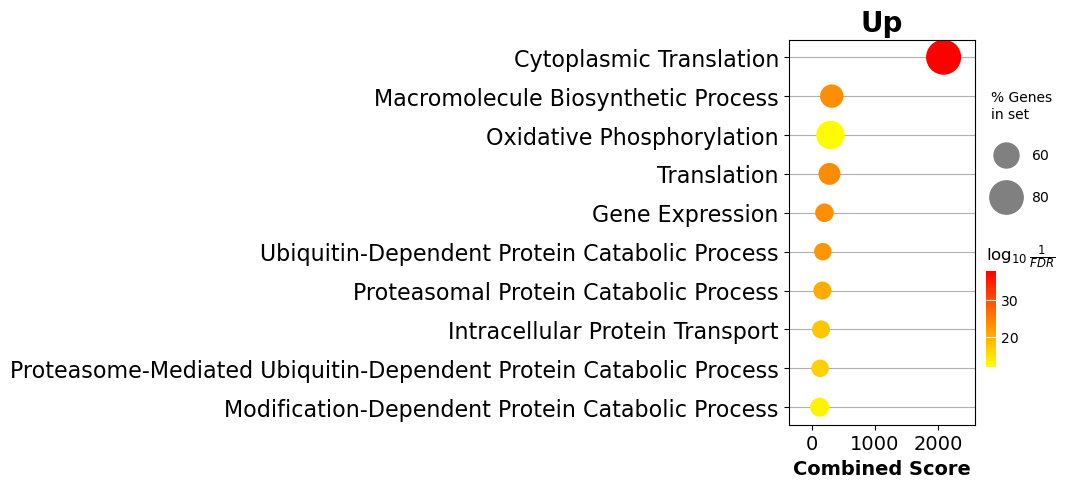

In [73]:
# dotplot
enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_up.res2d, figsize=(3,5), title="Up", cmap = plt.cm.autumn_r)
plt.show()

In [74]:
enr_dw = gp.enrichr(degs_dw.old_pop_names,
                    gene_sets='GO_Biological_Process_2025',
                    outdir=None)

In [75]:
enr_dw.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Muscle Contraction (GO:0006936),18/97,4.619546e-08,0.000105,0,0,5.593539,94.477028,RYR1;ROCK1;ROCK2;TPM2;TPM1;LMOD1;SLC8A1;LMOD3;...
1,GO_Biological_Process_2025,Regulation of mRNA Processing (GO:0050684),11/37,1.242751e-07,0.000142,0,0,10.322323,164.132873,SRPK2;RBM39;CDK11A;SON;SLTM;YTHDC1;SAFB2;LARP7...
2,GO_Biological_Process_2025,Chromatin Remodeling (GO:0006338),28/262,2.210641e-06,0.001680,0,0,2.951619,38.436653,KMT2E;KDM5A;HDAC4;SETD2;TRRAP;CHD6;PSIP1;RSF1;...
3,GO_Biological_Process_2025,Actomyosin Structure Organization (GO:0031032),14/85,6.236887e-06,0.003555,0,0,4.818017,57.744072,MYOM1;MYBPC1;ROCK1;EPB41;ROCK2;TPM1;LMOD1;CDC4...
4,GO_Biological_Process_2025,Regulation of mRNA Metabolic Process (GO:1903311),6/17,3.334586e-05,0.015206,0,0,13.234341,136.427222,SRPK2;CDK11A;SLTM;SAFB2;CDK11B;IWS1
...,...,...,...,...,...,...,...,...,...,...
2275,GO_Biological_Process_2025,Translation (GO:0006412),2/232,9.991848e-01,0.999990,0,0,0.207525,0.000169,EEF2K;MRPS5
2276,GO_Biological_Process_2025,Proteasomal Protein Catabolic Process (GO:0010...,5/372,9.992319e-01,0.999990,0,0,0.324017,0.000249,ZNRF1;FBXW7;ERCC8;UBXN4;TOPORS
2277,GO_Biological_Process_2025,Cytokine-Mediated Signaling Pathway (GO:0019221),2/255,9.996530e-01,0.999990,0,0,0.188431,0.000065,IKBKB;JAK2
2278,GO_Biological_Process_2025,Proteolysis (GO:0006508),2/321,9.999684e-01,0.999990,0,0,0.148925,0.000005,PRSS50;ADAMTS19


<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_101622/1711771011.py:1: SyntaxWarning: invalid escape sequence '\('
  enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]


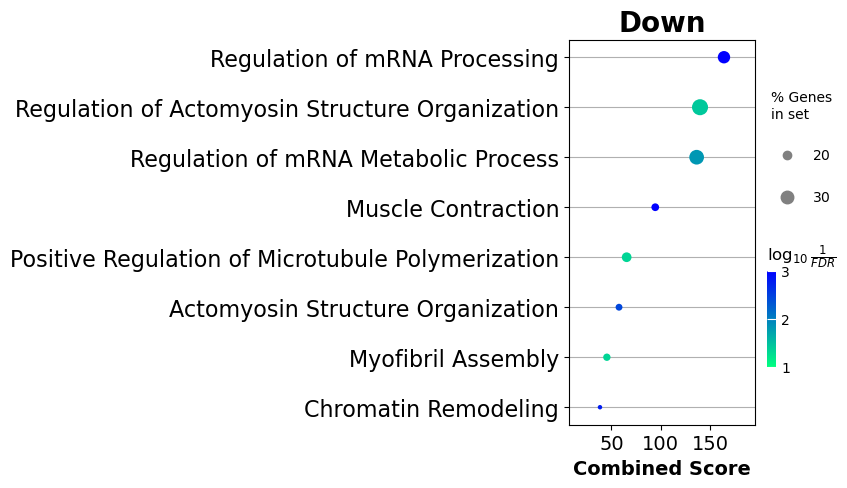

In [76]:
enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_dw.res2d,
           figsize=(3,5),
           title="Down",
           cmap = plt.cm.winter_r,
           size=5)
plt.show()